# Notebook 03. GTSRB Transfer Learning with PyTorch 🚦

In the previous notebook, we built CNN models from scratch and improved the validation accuracy from around `92%` to `99.44%`.

Now we will study **Transfer Learning**.

Instead of training every feature from zero, we will use a model already trained on a large image dataset and adapt it for **43-class GTSRB traffic sign classification**.

## 1. Transfer Learning Project Contract 📌

This notebook focuses on learning transfer learning step by step.

We will compare pretrained models against our best from-scratch CNN model.

### 1.1 Problem Statement 🎯

**Goal:**  
Classify German traffic sign images into `43` classes using transfer learning.

**Previous benchmark:**  
Our best from-scratch model was **Model 4**, which achieved around `99.44%` validation accuracy.

**Main question:**  
Can a pretrained model match or beat our best from-scratch CNN?

**What we will do in this notebook:**

1. Load the saved train/validation/test splits  
2. Build a transfer learning data pipeline  
3. Use a pretrained `ResNet18` model  
4. Train it first as a **feature extractor**  
5. Then fine-tune deeper layers  
6. Compare transfer learning results with our from-scratch Model 4  
7. Finally evaluate the best model on the official test set  

**Experiment rule:**  
We will go slowly and understand each transfer learning step before writing the code.

**Useful reference:**  
PyTorch Transfer Learning Tutorial + TorchVision pretrained model documentation.

### 1.2 Previous From-Scratch Benchmark 🧪

Before transfer learning, we trained multiple CNN models from scratch.

The goal was to understand how different improvements affect GTSRB traffic sign classification.

| Model | Main Idea | Best Validation Accuracy | Main Finding |
|---|---|---:|---|
| Model 0 | Simple CNN baseline | `~92.54%` | Good starting point, but overfitting and class confusion existed |
| Model 1 | CNN + BatchNorm | `~96.07%` | BatchNorm improved training stability and generalization |
| Model 2 | BatchNorm + Safe Augmentation | `~95.46%` | Augmentation regularized training but did not beat Model 1 |
| Model 3 | BatchNorm + Dropout | `~95.80%` | Dropout helped, but still did not beat Model 1 |
| Model 4 | Deeper CNN + BatchNorm + Dropout + AdaptiveAvgPool | `~99.44%` | Best from-scratch model |

✅ **Best from-scratch model:** `Model 4`  
✅ **Validation accuracy:** `99.44%`  
✅ **Wrong predictions:** `44 / 7860`  
✅ **Wrong prediction rate:** `0.56%`

#### Why Model 4 worked best 🔍

Model 4 improved strongly because it changed the architecture in a meaningful way.

Instead of using a shallow CNN with a large flatten classifier, Model 4 used:

- deeper convolution blocks
- repeated `Conv2d → BatchNorm2d → ReLU`
- `Dropout` for regularization
- `AdaptiveAvgPool2d` before the classifier
- a smaller final classifier

This helped the model learn stronger visual features before classification.

The biggest lesson from the previous notebook:

> Architecture improvement helped more than simply adding augmentation or dropout.

So, in this notebook, transfer learning must beat a very strong benchmark, not a weak baseline.

### 1.3 Research Questions 🔬

In this notebook, we will use transfer learning and try to answer a few important questions.

These questions will guide our experiments.

#### Main Research Question 🎯

**Can transfer learning match or beat our best from-scratch Model 4?**

Our previous best model achieved around `99.44%` validation accuracy.

So transfer learning has a very strong benchmark to beat.

#### Experiment Questions 🧠

1. **Is a pretrained model useful for GTSRB traffic sign classification?**  
   We will test whether a model pretrained on ImageNet can learn traffic signs effectively.

2. **Is feature extraction enough?**  
   We will freeze the pretrained backbone and train only the new classifier head.

3. **Does fine-tuning improve the result?**  
   We will unfreeze deeper layers and check whether the model improves after learning task-specific features.

4. **Does transfer learning reduce difficult class mistakes?**  
   We will check whether transfer learning improves weak classes such as visually similar speed-limit signs, triangular warning signs, and blue circular signs.

5. **Does transfer learning make fewer high-confidence wrong predictions?**  
   We will inspect wrong predictions and confidence scores.

6. **Which approach is better for this project?**  
   We will compare:

   - best from-scratch CNN
   - ResNet18 feature extractor
   - ResNet18 fine-tuned model
   - optional EfficientNet-B0 model

#### Decision Goal ✅

At the end of this notebook, we want to decide:

- whether transfer learning is better than our from-scratch Model 4
- whether feature extraction is enough
- whether fine-tuning is worth it
- which model should be used for final official test evaluation

This notebook is not only about getting high accuracy.  
It is also about understanding how transfer learning works step by step.

### 1.4 Experiment Rules 🧭

To keep this transfer learning notebook clean and fair, we will follow fixed experiment rules.

These rules will help us compare models properly and avoid messy experiments.

### 1.4 Experiment Rules 🧭

To keep this transfer learning notebook clean, fair, and easy to understand, we will follow these rules:

| Rule | Meaning |
|---|---|
| 🔒 Same data split | Use the saved train/validation/test split from the previous notebook. No new random split. |
| 🧪 One major change at a time | First feature extraction, then fine-tuning. Do not mix many changes together. |
| 🖼️ Model-specific preprocessing | Use the transform connected to the pretrained weights, including resize/crop and normalization. |
| 🧠 Core learning stays in notebook | Pretrained model loading, freezing, unfreezing, classifier replacement, and optimizer parameter groups will stay in the notebook. |
| 🧰 Helper file only for utilities | Helper functions will handle repeated support tasks like parameter summary, checkpoint save/load, and experiment rows. |
| 💾 Save best checkpoint | Save the model weights from the epoch with the best validation accuracy, not just the final epoch. |
| 📊 Same evaluation metrics | Evaluate every model with accuracy, classification report, confusion matrix, per-class accuracy, and wrong prediction analysis. |
| ⚔️ Compare with Model 4 | Every transfer learning result will be compared with the best from-scratch Model 4 benchmark: `99.44%` validation accuracy. |
| 🚫 Test set only at the end | The official test set will not be used for model selection or tuning. |
| ✍️ Explain before code | Follow: `Concept → Code → Output → Observation → Decision`. |

**Decision:**  
Every experiment must be reproducible, fairly compared, clearly explained, saved with a checkpoint, and compared against our from-scratch benchmark.

### 1.5 Success Criteria ✅

This notebook will be successful if we can clearly answer whether transfer learning is useful for this GTSRB project.

| Criteria | Meaning |
|---|---|
| 🎯 Beat or match benchmark | Transfer learning should try to match or beat our from-scratch Model 4 validation accuracy: `99.44%`. |
| 📉 Reduce wrong predictions | A good transfer learning model should reduce or stay close to the `44` wrong predictions from Model 4. |
| 🧠 Explainable improvement | If performance improves, we should understand why: feature extraction, fine-tuning, better pretrained features, or better preprocessing. |
| 📊 Fair evaluation | Every model must be evaluated with the same validation split and same metrics. |
| 💾 Best model saved | The best validation checkpoint must be saved for each transfer learning experiment. |
| 🧪 Honest test evaluation | The official test set will be used only after selecting the final best model. |

**Main success question:**  
Can transfer learning give better performance than our best from-scratch CNN, or does our custom Model 4 remain stronger?

**Decision rule:**  
If transfer learning beats Model 4 or reduces important error patterns, it becomes the final candidate.  
If not, Model 4 remains our best from-scratch solution.

## 2. Setup and Saved Split Loading ⚙️

In this section, we will prepare the notebook environment.



### 2.1 Import Libraries 📦

First, we will import the basic libraries needed for data handling, visualization, PyTorch, and training utilities.

In [1]:
from pathlib import Path
import sys
import json
import copy
from timeit import default_timer as timer

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torchvision
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from PIL import Image
from tqdm.auto import tqdm

print("Python libraries imported successfully.")
print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)

Python libraries imported successfully.
PyTorch version: 2.11.0+cu128
Torchvision version: 0.26.0+cu128


### 2.2 Set Project Paths 🗂️

Now we will define the main project folders.

This makes the notebook work even if we run it from inside the `Notebook` folder.

In [2]:
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name.lower() == "notebook":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "Data"
PROCESSED_DATA_DIR = PROJECT_ROOT / "Processed_Data"
REPORT_DIR = PROJECT_ROOT / "Report"
TRAINED_MODEL_DIR = PROJECT_ROOT / "Trained_model"
SRC_DIR = PROJECT_ROOT / "src"

print("Current directory:", CURRENT_DIR)
print("Project root:", PROJECT_ROOT)
print("Data directory:", DATA_DIR)
print("Processed data directory:", PROCESSED_DATA_DIR)
print("Report directory:", REPORT_DIR)
print("Trained model directory:", TRAINED_MODEL_DIR)
print("Source directory:", SRC_DIR)

Current directory: c:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Deep_Learning\Pytorch-German-Traffic-Sign-Recognition\Notebook
Project root: c:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Deep_Learning\Pytorch-German-Traffic-Sign-Recognition
Data directory: c:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Deep_Learning\Pytorch-German-Traffic-Sign-Recognition\Data
Processed data directory: c:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Deep_Learning\Pytorch-German-Traffic-Sign-Recognition\Processed_Data
Report directory: c:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Deep_Learning\Pytorch-German-Traffic-Sign-Recognition\Report
Trained model directory: c:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Deep_Learning\Pytorch-German-Traffic-Sign-Recognition\Trained_model
Source directory: c:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Deep_Learning\Pytorch-German-Traffic-Sign-Recognition\src


### 2.3 Load Helper Files 🧰

We will load two helper files:

- `helper_functions.py` for general project utilities
- `transfer_learning_helpers.py` for transfer-learning-specific utilities

Core transfer learning logic will still stay inside this notebook.

In [3]:
import importlib

from src import helper_functions as hf
from src import transfer_learning_helpers as tlh

importlib.reload(hf)
importlib.reload(tlh)

print("General helper functions loaded:", hf.__name__)
print("Transfer learning helper functions loaded:", tlh.__name__)

General helper functions loaded: src.helper_functions
Transfer learning helper functions loaded: src.transfer_learning_helpers


### 2.4 Load Saved Train/Validation/Test Splits 📂

We will load the saved train, validation, and test dataframes from the previous notebook.

This keeps the transfer learning experiment fair because we are using the same split as the from-scratch models.

In [4]:
train_split_df = pd.read_csv(PROCESSED_DATA_DIR / "train_split_df.csv")
valid_split_df = pd.read_csv(PROCESSED_DATA_DIR / "valid_split_df.csv")
test_df = pd.read_csv(PROCESSED_DATA_DIR / "test_df.csv")

print("Train split shape:", train_split_df.shape)
print("Validation split shape:", valid_split_df.shape)
print("Test set shape:", test_df.shape)

display(train_split_df.head())

Train split shape: (31349, 10)
Validation split shape: (7860, 10)
Test set shape: (12630, 9)


,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path,full_path,track_id
0,27,26,5,5,22,20,20,Train/20/00020_00000_00000.png,c:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\D...,00020_00000
1,28,27,5,6,23,22,20,Train/20/00020_00000_00001.png,c:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\D...,00020_00000
2,29,26,6,5,24,21,20,Train/20/00020_00000_00002.png,c:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\D...,00020_00000
3,28,27,5,6,23,22,20,Train/20/00020_00000_00003.png,c:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\D...,00020_00000
4,28,26,5,5,23,21,20,Train/20/00020_00000_00004.png,c:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\D...,00020_00000


#### 2.4 Observation 📝

The saved data splits are loaded successfully.

We will use:

- training split for model training
- validation split for model selection
- official test set only for final evaluation

This keeps the transfer learning results comparable with the previous from-scratch CNN experiments.

### 2.5 Device and Seed Setup ⚡

Now we will set the random seed and choose the training device.

If CUDA is available, we will train on GPU.

In [5]:
SEED = 42

generator = hf.set_seeds(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"

NUM_WORKERS = 0
PIN_MEMORY = True if device == "cuda" else False

print("Seed:", SEED)
print("Device:", device)

if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

print("Num workers:", NUM_WORKERS)
print("Pin memory:", PIN_MEMORY)

Seed: 42
Device: cuda
GPU: NVIDIA GeForce RTX 5060 Ti
Num workers: 0
Pin memory: True


### 2.6 Quick Split Sanity Check 🔍

Before starting transfer learning, we will check whether the saved splits are still valid.

We will check:

- number of images
- number of classes
- image path overlap
- track ID overlap
- missing image paths

In [6]:
train_paths, valid_paths, test_paths = set(train_split_df["full_path"]), set(valid_split_df["full_path"]), set(test_df["full_path"])
train_track_ids, valid_track_ids = set(train_split_df["track_id"]), set(valid_split_df["track_id"])

train_valid_path_overlap = train_paths.intersection(valid_paths)
train_test_path_overlap = train_paths.intersection(test_paths)
valid_test_path_overlap = valid_paths.intersection(test_paths)
track_id_overlap = train_track_ids.intersection(valid_track_ids)

missing_train_paths = train_split_df["full_path"].apply(lambda x: not Path(x).exists()).sum()
missing_valid_paths = valid_split_df["full_path"].apply(lambda x: not Path(x).exists()).sum()
missing_test_paths = test_df["full_path"].apply(lambda x: not Path(x).exists()).sum()

split_sanity_df = pd.DataFrame({
    "check": ["train_images", "valid_images", "test_images", "train_classes", "valid_classes", "test_classes", "train_valid_path_overlap", "train_test_path_overlap", "valid_test_path_overlap", "train_valid_track_id_overlap", "missing_train_paths", "missing_valid_paths", "missing_test_paths"],
    "value": [len(train_split_df), len(valid_split_df), len(test_df), train_split_df["ClassId"].nunique(), valid_split_df["ClassId"].nunique(), test_df["ClassId"].nunique(), len(train_valid_path_overlap), len(train_test_path_overlap), len(valid_test_path_overlap), len(track_id_overlap), missing_train_paths, missing_valid_paths, missing_test_paths]
})

split_sanity_df

,check,value
0,train_images,31349
1,valid_images,7860
2,test_images,12630
3,train_classes,43
4,valid_classes,43
5,test_classes,43
6,train_valid_path_overlap,0
7,train_test_path_overlap,0
8,valid_test_path_overlap,0
9,train_valid_track_id_overlap,0


## 3. Transfer Learning Theory 🧠

Before writing transfer learning code, we need to understand the core ideas.

In this section, we will learn:

| Topic | Why it matters |
|---|---|
| Transfer learning | Why we use a pretrained model instead of training from zero |
| ImageNet pretraining | Where the pretrained visual knowledge comes from |
| Feature extraction | How to train only a new classifier head |
| Fine-tuning | How to update deeper pretrained layers |
| Freezing | How to stop selected weights from training |
| Classifier replacement | How to adapt a model to 43 GTSRB classes |
| Model-specific transforms | Why pretrained models need special preprocessing |
| 224×224 image size | Why many pretrained CNNs expect this input size |

**Goal:**  
Understand the idea first, then implement it step by step.

### 3.1 What is Transfer Learning? 🔁

**Transfer Learning** means using knowledge learned from one task and applying it to another related task.

Instead of starting from random weights, we start from a model that already learned useful image patterns from a large dataset.

| Training from Scratch | Transfer Learning |
|---|---|
| Starts with random weights | Starts with pretrained weights |
| Learns basic features from zero | Already knows basic image features |
| Needs more time and data | Often trains faster |
| Good for understanding CNN basics | Good for practical strong performance |

---

#### Simple example 🚦

A pretrained CNN may already understand many basic image patterns.

| Learned feature | How it helps in GTSRB |
|---|---|
| Edges | Detect traffic sign borders |
| Circles | Detect speed-limit signs |
| Triangles | Detect warning signs |
| Colors | Detect red, blue, yellow signs |
| Shapes | Detect symbols inside signs |

So the model does not start completely blind.

---

#### Core mathematical idea 🧮

A neural network takes an image and produces a prediction.

$$
\hat{y} = f(x; \theta)
$$

| Symbol | Simple name | Meaning |
|---|---|---|
| x | input image | traffic sign image |
| f | model | neural network function |
| theta | weights | learnable parameters |
| y_hat | prediction | predicted traffic sign class |

---

#### From-scratch training

In normal training from scratch, the model starts with random weights.

$$
\theta = \theta_{\text{random}}
$$

That means the model has no previous visual knowledge.

It must learn everything from the GTSRB dataset:

- edges
- shapes
- colors
- sign borders
- sign symbols
- class differences

---

#### Transfer learning training

In transfer learning, the model starts with pretrained weights.

$$
\theta = \theta_{\text{pretrained}}
$$

That means the model already learned useful visual features from another large image dataset.

Then we adapt that model for our own task.

---

#### Backbone + classifier idea 🧠

Most image classification models have two main parts:

| Part | Simple meaning | Job |
|---|---|---|
| Backbone | feature extractor | learns image patterns |
| Classifier head | final decision layer | predicts the class |

First, the backbone extracts useful features from the image.

$$
\text{features} = g(x; \theta_{\text{features}})
$$

Then, the classifier head uses those features to predict the class.

$$
\hat{y} = h(\text{features}; \theta_{\text{classifier}})
$$

Together, the full model becomes:

$$
\hat{y} = h(g(x; \theta_{\text{features}}); \theta_{\text{classifier}})
$$

---

#### For our GTSRB project 🚦

| Component | Our project example |
|---|---|
| Input image | traffic sign image |
| Backbone | pretrained ResNet18 |
| New classifier head | Linear layer for 43 classes |
| Output | predicted traffic sign class |

In simple words:

```text
Traffic sign image → pretrained backbone → extracted features → new classifier → class prediction

## 3.2 What is ImageNet Pretraining?

**ImageNet pretraining** means using a CNN model that has already learned useful visual features from a very large image dataset called **ImageNet**.

Instead of starting from random weights, we start from weights that were already trained on ImageNet.

In simple words:

> The model already has some general image understanding before it sees our GTSRB traffic sign images.

A pretrained model may already know visual patterns such as:

- edges
- corners
- curves
- colors
- textures
- shapes
- object boundaries

These features can help the model learn traffic signs faster.

---

### Training from scratch

When we train a CNN from scratch, the model weights are randomly initialized.

$$
W_0 = \text{random weights}
$$

Then the model learns features only from the GTSRB dataset.

The learning process looks like this:

$$
X_{\text{GTSRB}} \rightarrow \text{CNN with random weights} \rightarrow \hat{y}
$$

Here:

$$
X_{\text{GTSRB}} = \text{input traffic sign image}
$$

$$
\hat{y} = \text{predicted traffic sign class}
$$

So the model has to learn everything by itself:

$$
\text{edges} \rightarrow \text{shapes} \rightarrow \text{traffic sign patterns} \rightarrow \text{class prediction}
$$

---

### Training with ImageNet pretraining

In ImageNet pretraining, the model does not start from random weights.

It starts from weights already learned from ImageNet.

$$
W_0 = W_{\text{ImageNet}}
$$

So the model already has general visual knowledge.

The learning process becomes:

$$
X_{\text{GTSRB}} \rightarrow \text{CNN with ImageNet pretrained weights} \rightarrow \hat{y}
$$

Instead of learning from zero, the model adapts its existing knowledge to the GTSRB traffic sign task.

$$
\text{pretrained visual features} \rightarrow \text{traffic sign-specific features} \rightarrow \text{class prediction}
$$

---

### Simple example

Suppose the input image is a **Stop sign**.

A model trained from scratch needs to learn:

1. red color is important
2. octagon shape is important
3. white border or text is important
4. this combination represents a Stop sign

But an ImageNet pretrained model may already understand:

$$
\text{edges}, \text{corners}, \text{red regions}, \text{object boundaries}, \text{basic shapes}
$$

So for GTSRB, it mainly needs to learn:

$$
\text{general visual patterns} \rightarrow \text{traffic sign class}
$$

This can make training faster and sometimes improve performance.

---

### Mathematical view of a CNN

A CNN can be divided into two main parts:

$$
f(x) = h(g(x))
$$

Where:

$$
g(x) = \text{feature extractor}
$$

and

$$
h(x) = \text{classifier head}
$$

The feature extractor learns useful image features.

The classifier head uses those features to predict the final class.

---

### ImageNet pretrained feature extractor

For an ImageNet pretrained model, the feature extractor already has pretrained weights.

$$
g(x; W_{\text{ImageNet}})
$$

Here:

$$
W_{\text{ImageNet}} = \text{weights learned from ImageNet}
$$

So the model becomes:

$$
f(x) = h(g(x; W_{\text{ImageNet}}))
$$

For our GTSRB task, we use the pretrained feature extractor and replace the classifier head.

---

### Why do we replace the classifier head?

ImageNet pretrained models are usually trained for **1000 ImageNet classes**.

So the original classifier predicts:

$$
1000 \text{ classes}
$$

But GTSRB has only:

$$
43 \text{ classes}
$$

Therefore, the original classifier head is not suitable for our task.

For example, in ResNet18, the original final layer is:

$$
\text{Linear}(512, 1000)
$$

This means:

$$
512 \text{ input features} \rightarrow 1000 \text{ ImageNet classes}
$$

For GTSRB, we replace it with:

$$
\text{Linear}(512, 43)
$$

This means:

$$
512 \text{ input features} \rightarrow 43 \text{ traffic sign classes}
$$

So the new GTSRB model becomes:

$$
f_{\text{GTSRB}}(x) = h_{\text{new}}(g(x; W_{\text{ImageNet}}))
$$

Where:

$$
h_{\text{new}} = \text{new classifier head for 43 GTSRB classes}
$$

---

### ImageNet pretraining intuition

The main idea is:

$$
\text{Random initialization} \rightarrow \text{learn everything from zero}
$$

But with transfer learning:

$$
\text{ImageNet initialization} \rightarrow \text{adapt existing visual knowledge}
$$

So the pretrained model gives us a better starting point.

---

### Important limitation

ImageNet and GTSRB are different datasets.

ImageNet contains general objects such as animals, vehicles, furniture, and everyday objects.

GTSRB contains only traffic signs.

So ImageNet pretraining may help, but it is not guaranteed to always perform better than a strong custom CNN trained directly on GTSRB.

In this project, our previous from-scratch CNN already achieved a very strong validation result.

Therefore, transfer learning will be tested as an experiment.

We will check whether ImageNet pretrained models can:

1. match the from-scratch CNN,
2. improve the result,
3. or show that a custom CNN is better for this specific dataset.

---

### Key takeaway

ImageNet pretraining means starting from a model that already learned general image features.

For GTSRB:

$$
\text{Pretrained ImageNet knowledge} + \text{GTSRB classifier head} = \text{Transfer learning model}
$$

This allows us to test whether general visual knowledge from ImageNet can help traffic sign classification.

## 3.3 Feature Extraction vs Fine-Tuning

In transfer learning, there are two common ways to use a pretrained model:

1. **Feature extraction**
2. **Fine-tuning**

Both methods use a model pretrained on a large dataset like ImageNet, but they update different parts of the model during training.

---

### Basic idea

A pretrained CNN can be divided into two main parts:

$$
f(x) = h(g(x))
$$

Where:

$$
g(x) = \text{feature extractor or backbone}
$$

and

$$
h(x) = \text{classifier head}
$$

The **feature extractor** learns image patterns such as edges, colors, textures, shapes, and object parts.

The **classifier head** uses those extracted features to predict the final class.

For our GTSRB task:

$$
x = \text{traffic sign image}
$$

$$
\hat{y} = \text{predicted traffic sign class}
$$

So the model becomes:

$$
f_{\text{GTSRB}}(x) = h_{\text{new}}(g(x))
$$

---

## 3.3.1 Feature Extraction

**Feature extraction** means we use the pretrained model as a fixed feature extractor.

In this method, we freeze the pretrained backbone and train only the new classifier head.

That means the ImageNet-learned feature extractor is not updated.

---

### Feature extraction formula

The pretrained feature extractor is kept fixed:

$$
g(x; W_{\text{ImageNet}})
$$

Here:

$$
W_{\text{ImageNet}} = \text{frozen pretrained weights}
$$

Only the new classifier head is trained:

$$
h_{\text{new}}(z; W_{\text{head}})
$$

Where:

$$
z = g(x; W_{\text{ImageNet}})
$$

So the full model is:

$$
f_{\text{GTSRB}}(x) = h_{\text{new}}(g(x; W_{\text{ImageNet}}))
$$

During training:

$$
W_{\text{ImageNet}} = \text{fixed}
$$

$$
W_{\text{head}} = \text{updated}
$$

---

### Simple explanation

In feature extraction, the model says:

> I already know general image features from ImageNet.  
> I will keep that knowledge fixed and only learn how to classify GTSRB traffic signs.

So the backbone works like a ready-made feature detector.

Only the final classifier learns the 43 GTSRB classes.

---

### Example with ResNet18

Original ImageNet ResNet18:

$$
\text{ResNet18} = \text{Backbone} + \text{Linear}(512, 1000)
$$

Because ImageNet has 1000 classes.

For GTSRB, we replace the classifier head:

$$
\text{Linear}(512, 1000) \rightarrow \text{Linear}(512, 43)
$$

Now the model becomes:

$$
\text{ResNet18}_{\text{GTSRB}} = \text{Frozen Backbone} + \text{Linear}(512, 43)
$$

Only this part is trained:

$$
\text{Linear}(512, 43)
$$

The backbone remains frozen.

---

### Trainable parameters in feature extraction

If a parameter has:

$$
\text{requires\_grad} = \text{False}
$$

then that parameter is frozen.

If a parameter has:

$$
\text{requires\_grad} = \text{True}
$$

then that parameter is trainable.

For feature extraction:

$$
\text{Backbone parameters} \rightarrow \text{requires\_grad} = \text{False}
$$

$$
\text{Classifier head parameters} \rightarrow \text{requires\_grad} = \text{True}
$$

---

### Advantages of feature extraction

Feature extraction is useful because:

1. it is faster to train,
2. it needs less GPU memory,
3. it reduces overfitting risk,
4. it works well when the target dataset is small,
5. it is a good first transfer learning baseline.

---

### Limitation of feature extraction

The main limitation is that the backbone cannot adapt to the new dataset.

ImageNet images and GTSRB images are different.

ImageNet contains general objects, but GTSRB contains traffic signs only.

So some ImageNet features may not be perfect for traffic sign classification.

Because the backbone is frozen, the model may not fully learn traffic sign-specific features.

---

## 3.3.2 Fine-Tuning

**Fine-tuning** means we allow some pretrained layers to update during training.

In this method, the model starts with ImageNet pretrained weights, but some layers are unfrozen and adapted to the GTSRB dataset.

---

### Fine-tuning formula

In fine-tuning, some backbone weights are updated.

We can write the model as:

$$
f_{\text{GTSRB}}(x) = h_{\text{new}}(g(x; W_{\text{ImageNet}}))
$$

But now:

$$
W_{\text{ImageNet}} \rightarrow W_{\text{GTSRB}}
$$

This means the pretrained weights are adjusted for the traffic sign dataset.

During training:

$$
W_{\text{head}} = \text{updated}
$$

and some backbone weights are also updated:

$$
W_{\text{backbone selected layers}} = \text{updated}
$$

---

### Simple explanation

In fine-tuning, the model says:

> I already know general image features from ImageNet,  
> but now I will slightly adjust some of my knowledge for GTSRB traffic signs.

So the model does not learn from zero.

It starts from pretrained knowledge and improves it for our specific task.

---

### Example with ResNet18

A ResNet18 model has several major blocks:

$$
\text{Conv1} \rightarrow \text{Layer1} \rightarrow \text{Layer2} \rightarrow \text{Layer3} \rightarrow \text{Layer4} \rightarrow \text{FC}
$$

In feature extraction:

$$
\text{Conv1, Layer1, Layer2, Layer3, Layer4} = \text{frozen}
$$

$$
\text{FC} = \text{trainable}
$$

In fine-tuning, we may unfreeze the last block:

$$
\text{Layer4} = \text{trainable}
$$

$$
\text{FC} = \text{trainable}
$$

But earlier layers can remain frozen:

$$
\text{Conv1, Layer1, Layer2, Layer3} = \text{frozen}
$$

So our fine-tuned model becomes:

$$
\text{ResNet18}_{\text{GTSRB}} = \text{Frozen early layers} + \text{Trainable Layer4} + \text{Trainable FC}
$$

---

### Why fine-tune only later layers?

Early CNN layers usually learn general patterns:

$$
\text{edges}, \text{corners}, \text{colors}, \text{basic textures}
$$

These are useful for many image datasets.

Later CNN layers learn more task-specific patterns:

$$
\text{object parts}, \text{specific shapes}, \text{class-level patterns}
$$

For GTSRB, traffic sign-specific patterns are more likely to be learned in the later layers.

So we usually fine-tune the last few layers first.

---

### Learning rate in fine-tuning

Fine-tuning usually needs a smaller learning rate for pretrained layers.

Because pretrained weights already contain useful knowledge, we do not want to destroy them.

So we can use different learning rates:

$$
\eta_{\text{backbone}} < \eta_{\text{classifier}}
$$

For example:

$$
\eta_{\text{backbone}} = 1 \times 10^{-5}
$$

$$
\eta_{\text{classifier}} = 1 \times 10^{-3}
$$

This means:

- backbone learns slowly,
- classifier head learns faster.

---

### Why smaller learning rate for backbone?

If the learning rate is too high, the pretrained features may change too quickly.

This can damage the useful ImageNet knowledge.

This problem is sometimes called forgetting pretrained knowledge.

So in fine-tuning, we update pretrained layers carefully.

---

## Feature Extraction vs Fine-Tuning Comparison

| Topic | Feature Extraction | Fine-Tuning |
|---|---|---|
| Backbone | Frozen | Partially trainable |
| Classifier head | Trainable | Trainable |
| Speed | Faster | Slower |
| GPU memory | Lower | Higher |
| Overfitting risk | Lower | Higher |
| Adaptation to GTSRB | Limited | Better |
| Best use case | First baseline | Improved transfer learning experiment |

---

## Project decision

For this project, we will test both approaches.

First, we will use **ResNet18 as a feature extractor**.

That means:

$$
\text{Frozen ResNet18 backbone} + \text{new 43-class classifier head}
$$

Then, if needed, we will apply **fine-tuning**.

That means:

$$
\text{Frozen early layers} + \text{trainable Layer4} + \text{new 43-class classifier head}
$$

This experiment will help us answer:

$$
\text{Is ImageNet feature extraction enough for GTSRB?}
$$

and

$$
\text{Does fine-tuning improve performance on traffic signs?}
$$

---

### Key takeaway

Feature extraction trains only the new classifier head.

$$
\text{Feature Extraction} = \text{Frozen Backbone} + \text{Trainable Classifier}
$$

Fine-tuning trains the classifier head and also updates some pretrained layers.

$$
\text{Fine-Tuning} = \text{Partially Trainable Backbone} + \text{Trainable Classifier}
$$

In our transfer learning workflow, feature extraction will be the first baseline, and fine-tuning will be the next improvement step.

## 3.4 What Does Freezing Mean?

In transfer learning, **freezing** means keeping some pretrained model weights fixed during training.

A pretrained model already learned useful visual features from ImageNet.
If we freeze some layers, their weights will not be updated by our GTSRB training data.

In simple words:

> Freezing means the layer is used for feature extraction, but it does not learn new weights.

---

### Normal training weight update

During normal training, model weights are updated using backpropagation.

The basic update rule is:

$$
W_{\text{new}} = W_{\text{old}} - \eta \frac{\partial L}{\partial W}
$$

Where:

$$
W = \text{model weight}
$$

$$
\eta = \text{learning rate}
$$

$$
L = \text{loss}
$$

$$
\frac{\partial L}{\partial W} = \text{gradient of loss with respect to weight}
$$

This means the model checks the loss and updates the weights to reduce future error.

---

### Frozen layer weight update

If a layer is frozen, its weights are not updated.

So for a frozen layer:

$$
W_{\text{new}} = W_{\text{old}}
$$

The gradient update is not applied to that layer.

In PyTorch, this is controlled using:

```python
param.requires_grad = False
```

If:

```python
requires_grad = False
```

then the parameter is frozen.

If:

```python
requires_grad = True
```

then the parameter is trainable.

---

### Freezing in ResNet18

A ResNet18 model has several major parts:

$$
\text{Conv1} \rightarrow \text{Layer1} \rightarrow \text{Layer2} \rightarrow \text{Layer3} \rightarrow \text{Layer4} \rightarrow \text{FC}
$$

In feature extraction, we freeze the backbone:

$$
\text{Conv1, Layer1, Layer2, Layer3, Layer4} = \text{frozen}
$$

and train only the classifier head:

$$
\text{FC} = \text{trainable}
$$

So the model becomes:

$$
\text{Frozen ImageNet Backbone} + \text{Trainable GTSRB Classifier Head}
$$

---

### Example

Suppose ResNet18 already learned from ImageNet how to detect:

$$
\text{edges}, \text{corners}, \text{colors}, \text{textures}, \text{shapes}
$$

For GTSRB, we can freeze those learned layers.

Then the frozen backbone will extract features from traffic sign images.

After that, the new classifier head will learn:

$$
\text{extracted features} \rightarrow \text{43 traffic sign classes}
$$

So the pretrained backbone works like a fixed feature detector.

---

### Why do we freeze layers?

We freeze layers because:

1. the pretrained model already learned useful general image features,
2. freezing reduces training time,
3. freezing reduces GPU memory usage,
4. freezing reduces overfitting risk,
5. it gives a simple transfer learning baseline.

This is especially useful when the target dataset is not very large.

---

### Limitation of freezing

The limitation is that frozen layers cannot adapt to the new dataset.

ImageNet and GTSRB are different.

ImageNet contains general objects, but GTSRB contains traffic signs.

So if all backbone layers are frozen, the model may not fully learn traffic sign-specific features.

That is why after feature extraction, we may try fine-tuning.

---

### Key takeaway

Freezing means:

$$
\text{Use pretrained layers, but do not update their weights}
$$

For feature extraction:

$$
\text{Frozen Backbone} + \text{Trainable Classifier Head}
$$

For fine-tuning:

$$
\text{Some Frozen Layers} + \text{Some Trainable Layers} + \text{Trainable Classifier Head}
$$

---

## 3.5 What Does Replacing Classifier Head Mean?

A pretrained CNN has two main parts:

$$
f(x) = h(g(x))
$$

Where:

$$
g(x) = \text{feature extractor or backbone}
$$

and

$$
h(x) = \text{classifier head}
$$

The backbone extracts visual features from the image.

The classifier head converts those features into class predictions.

---

### Why do we need to replace the classifier head?

ImageNet pretrained models are trained to classify **1000 ImageNet classes**.

So the original model predicts:

$$
1000 \text{ classes}
$$

But our GTSRB dataset has:

$$
43 \text{ traffic sign classes}
$$

Therefore, the original ImageNet classifier head is not correct for our project.

We need a new classifier head that predicts 43 classes instead of 1000 classes.

---

### ResNet18 example

In ResNet18, the original final classifier layer is:

$$
\text{Linear}(512, 1000)
$$

This means:

$$
512 \text{ input features} \rightarrow 1000 \text{ ImageNet classes}
$$

But for GTSRB, we need:

$$
\text{Linear}(512, 43)
$$

This means:

$$
512 \text{ input features} \rightarrow 43 \text{ traffic sign classes}
$$

So we replace:

$$
h_{\text{ImageNet}} = \text{Linear}(512, 1000)
$$

with:

$$
h_{\text{GTSRB}} = \text{Linear}(512, 43)
$$

---

### Final model after replacing classifier head

Before replacement:

$$
f_{\text{ImageNet}}(x) = h_{\text{ImageNet}}(g(x; W_{\text{ImageNet}}))
$$

After replacement:

$$
f_{\text{GTSRB}}(x) = h_{\text{GTSRB}}(g(x; W_{\text{ImageNet}}))
$$

Here:

$$
g(x; W_{\text{ImageNet}}) = \text{pretrained feature extractor}
$$

and:

$$
h_{\text{GTSRB}} = \text{new classifier head for 43 traffic sign classes}
$$

---

### Simple example

Imagine the pretrained model is a student who studied 1000 general objects:

$$
\text{cat}, \text{dog}, \text{car}, \text{chair}, \text{bird}, \ldots
$$

But now we want the model to answer traffic sign classes:

$$
\text{Speed Limit}, \text{Stop}, \text{Yield}, \text{No Entry}, \ldots
$$

The old final exam had 1000 possible answers.

Our new final exam has 43 possible answers.

So we keep the visual knowledge, but replace the final answer sheet.

That replacement is called replacing the classifier head.

---

### PyTorch idea

For ResNet18, the classifier head is usually called:

```python
model.fc
```

So we replace it like this:

```python
model.fc = nn.Linear(512, 43)
```

In actual code, it is safer to get the input feature size from the model:

```python
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, 43)
```

This makes the code more flexible.

---

### Key takeaway

Replacing classifier head means:

$$
\text{Old ImageNet classifier} \rightarrow \text{New GTSRB classifier}
$$

For ResNet18:

$$
\text{Linear}(512, 1000) \rightarrow \text{Linear}(512, 43)
$$

The backbone keeps pretrained visual knowledge, but the final layer learns our 43 traffic sign classes.

---

## 3.6 Why Pretrained Models Need Different Transforms

Pretrained models need specific image transforms because they were originally trained using a specific input format.

If we use a pretrained ImageNet model, we should prepare our images in a similar way to ImageNet training.

Otherwise, the input image distribution may be different from what the model expects.

---

### What does transform mean?

A transform means image preprocessing before sending the image into the model.

Common transforms include:

* resizing image
* converting image to tensor
* normalizing pixel values
* applying data augmentation

For transfer learning, transforms are very important.

---

### Why transforms matter

A CNN does not see images like humans.

It sees numbers.

An image is converted into pixel values.

For RGB images, each image has three color channels:

$$
R, G, B
$$

Before normalization, pixel values may be in the range:

$$
0 \text{ to } 255
$$

After converting to tensor, pixel values are usually scaled to:

$$
0 \text{ to } 1
$$

Then normalization changes them using mean and standard deviation.

---

### Normalization formula

Normalization is done as:

$$
x_{\text{norm}} = \frac{x - \mu}{\sigma}
$$

Where:

$$
x = \text{pixel value}
$$

$$
\mu = \text{mean}
$$

$$
\sigma = \text{standard deviation}
$$

For ImageNet pretrained models, we usually use ImageNet mean and standard deviation:

$$
\mu = [0.485, 0.456, 0.406]
$$

$$
\sigma = [0.229, 0.224, 0.225]
$$

These values are for the RGB channels.

So the image is normalized as:

$$
R_{\text{norm}} = \frac{R - 0.485}{0.229}
$$

$$
G_{\text{norm}} = \frac{G - 0.456}{0.224}
$$

$$
B_{\text{norm}} = \frac{B - 0.406}{0.225}
$$

---

### Why ImageNet normalization?

The pretrained model learned its weights using ImageNet-normalized images.

So during transfer learning, if we also use ImageNet normalization, the input distribution becomes more familiar to the model.

If we use a very different normalization, the model may receive image values in a format it was not trained for.

This can reduce performance.

---

### Example

Suppose ResNet18 learned from ImageNet images where the normalized input looked like this:

$$
\text{ImageNet-style input} \rightarrow \text{pretrained ResNet features}
$$

But if we send unnormalized GTSRB images:

$$
\text{different input scale} \rightarrow \text{less reliable features}
$$

The model may still run, but its pretrained feature extraction may not work as well.

---

### GTSRB transform decision

For our from-scratch CNN, we could choose custom transforms based on the GTSRB dataset.

But for pretrained models, we should follow the expected preprocessing of the pretrained model.

For ResNet18 transfer learning, a common transform is:

```python
transforms.Resize((224, 224))
transforms.ToTensor()
transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)
```

For training, we can also add light augmentation before normalization.

Example:

```python
transforms.Resize((224, 224))
transforms.RandomRotation(10)
transforms.ColorJitter(brightness=0.2, contrast=0.2)
transforms.ToTensor()
transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)
```

---

### Why not use very strong augmentation?

Traffic signs have important shapes, colors, and symbols.

If augmentation is too strong, the sign may become unrealistic.

For example:

* too much rotation can change the meaning,
* too much color change can damage important sign color,
* too much cropping can remove part of the sign.

So for GTSRB, augmentation should be useful but not extreme.

---

### Key takeaway

Pretrained models need different transforms because they expect input images similar to the images used during pretraining.

For ImageNet pretrained models:

$$
\text{Resize} + \text{ToTensor} + \text{ImageNet Normalization}
$$

This helps the pretrained backbone extract reliable features from our GTSRB images.

---

## 3.7 Why 224x224 Image Size Is Commonly Used

Many pretrained CNN models commonly use images with size:

$$
224 \times 224
$$

This means the image height is 224 pixels and the image width is 224 pixels.

For RGB images, the input shape becomes:

$$
3 \times 224 \times 224
$$

Where:

$$
3 = \text{RGB channels}
$$

$$
224 = \text{height}
$$

$$
224 = \text{width}
$$

---

### Why 224x224 is common

Many classic ImageNet pretrained models were trained using 224x224 images.

Examples include:

* ResNet18
* ResNet34
* VGG
* MobileNet
* DenseNet

Because these models were trained with this image size, using 224x224 during transfer learning is a safe and common choice.

---

### Model input expectation

A pretrained model learned features using a certain image scale.

For example, ResNet18 commonly expects input like:

$$
(N, 3, 224, 224)
$$

Where:

$$
N = \text{batch size}
$$

$$
3 = \text{RGB channels}
$$

$$
224 = \text{image height}
$$

$$
224 = \text{image width}
$$

So if our batch size is 32, the input shape becomes:

$$
(32, 3, 224, 224)
$$

---

### Why not keep the original GTSRB size?

GTSRB images can have different sizes.

Some images may be small.

But deep CNN models need images in a consistent size within a batch.

A DataLoader batch must have the same tensor shape for every image.

So we resize all images to one fixed size.

For transfer learning with ResNet18, 224x224 is a common fixed size.

---

### Simple example

Suppose we have three traffic sign images:

$$
40 \times 40
$$

$$
52 \times 48
$$

$$
80 \times 70
$$

They cannot be directly placed into the same batch because their sizes are different.

So we resize them:

$$
40 \times 40 \rightarrow 224 \times 224
$$

$$
52 \times 48 \rightarrow 224 \times 224
$$

$$
80 \times 70 \rightarrow 224 \times 224
$$

Now every image has the same size:

$$
3 \times 224 \times 224
$$

This allows batching and model training.

---

### Why 224x224 can help transfer learning

Using 224x224 helps because:

1. it matches common ImageNet pretrained model settings,
2. it gives the model enough spatial detail,
3. it makes input size consistent,
4. it works well with ResNet-style architectures,
5. it is a standard baseline for transfer learning experiments.

---

### Possible downside

Resizing small traffic sign images to 224x224 may increase computation.

It can also slightly distort images if aspect ratio is not handled carefully.

For example:

$$
40 \times 30 \rightarrow 224 \times 224
$$

may stretch the image.

However, for a simple and standard transfer learning baseline, resizing to 224x224 is acceptable.

Later, if needed, we can test other image sizes such as:

$$
128 \times 128
$$

or:

$$
160 \times 160
$$

But for the first transfer learning experiment, 224x224 is the safest and most standard choice.

---

### Important note for GTSRB

Traffic signs are usually centered and relatively simple objects.

So resizing them to 224x224 can work well with pretrained CNNs.

However, we should avoid aggressive cropping because cropping may remove important sign borders, symbols, or numbers.

For this project, using:

$$
\text{Resize}(224, 224)
$$

is safer than heavy cropping.

---

### Key takeaway

224x224 is commonly used because many ImageNet pretrained models were trained with this size.

For our transfer learning experiment:

$$
\text{GTSRB image} \rightarrow 224 \times 224 \rightarrow \text{Pretrained ResNet18}
$$

This gives the pretrained model an input format close to what it saw during ImageNet training.


# 4. Transfer Learning Data Pipeline

In the previous section, we discussed the theory behind ImageNet pretraining, freezing, classifier head replacement, pretrained transforms, and the common use of 224x224 image size.

In this section, we will implement the practical data pipeline for transfer learning. The goal is to prepare the GTSRB images in a format suitable for ImageNet-pretrained models such as ResNet18.

This step will focus on:

* choosing the image size and normalization strategy,
* creating training and validation/test transforms,
* rebuilding the Dataset class,
* creating DataLoaders,
* visualizing transformed images,
* and checking one batch before model training.

---

## 4.1 Choose Image Size and Normalization Strategy

For this transfer learning experiment, we will resize all images to:

$$
224 \times 224
$$

This size is commonly used with ImageNet-pretrained CNN models such as ResNet18.

Since ResNet18 was pretrained on ImageNet, we will also use ImageNet normalization values:

```python
IMAGE_SIZE = 224

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
```

We already discussed why pretrained models need ImageNet-style preprocessing in the theory section. Here, we will directly apply that decision to make the GTSRB images compatible with the pretrained backbone.

The final input image shape for ResNet18 will be:

$$
3 \times 224 \times 224
$$

Where:

* `3` means RGB color channels,
* `224` means image height,
* `224` means image width.

This gives us a consistent and pretrained-model-friendly input format for the transfer learning experiments.


In [7]:
IMAGE_SIZE = 224

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

## 4.2 Create Training Transform

Now we will create the training transform for the transfer learning experiment.

The training transform will resize each image to `224 x 224`, apply light augmentation, convert the image into a tensor, and normalize it using ImageNet mean and standard deviation.

Since traffic signs depend heavily on shape, color, symbol, and orientation, we will avoid aggressive augmentation such as horizontal flipping, heavy cropping, or large rotation.

In [8]:
from torchvision.transforms import InterpolationMode

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.RandomRotation(
        degrees=7,
        interpolation=InterpolationMode.BILINEAR,
        fill=(128, 128, 128)
    ),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

**Transform decision:**  
This training transform keeps augmentation moderate so that the traffic sign remains realistic and readable. The final normalized image tensor will be suitable for an ImageNet-pretrained ResNet18 model.

## 4.3 Create Validation/Test Transform

Now we will create the validation and test transform.

Unlike the training transform, the validation and test transform will not use random augmentation. During evaluation, we want stable and consistent input images so that the validation and test scores reflect the model's real performance.

Therefore, the validation/test transform will only resize the image, convert it to tensor, and apply ImageNet normalization.

In [9]:
valid_test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.ToTensor(),

    # ImageNet normalization for pretrained ResNet18
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

valid_test_transform

Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

## 4.4 Recreate GTSRB Dataset Class

Now we will recreate the custom PyTorch Dataset class for the transfer learning notebook.

This Dataset class will read image paths and labels from the saved split dataframes, open each image in RGB format, apply the selected transform, and return the image-label pair.

We are recreating the Dataset class here so that this transfer learning notebook remains self-contained and easy to follow.

In [10]:
class GTSRBDataset(Dataset):
    """
    Custom PyTorch Dataset for GTSRB traffic sign images.

    Each item returns:
        image tensor, label tensor
    """

    def __init__(
        self,
        df,
        image_col="full_path",
        label_col="ClassId",
        transform=None
    ):
        self.df = df.reset_index(drop=True)
        self.image_col = image_col
        self.label_col = label_col
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[index]

        image_path = row[self.image_col]
        label = row[self.label_col]

        image = Image.open(image_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        label = torch.tensor(label, dtype=torch.long)

        return image, label

In [11]:
# Quick Dataset class test with one training image
sample_dataset = GTSRBDataset(
    df=train_split_df,
    image_col="full_path",
    label_col="ClassId",
    transform=train_transform
)

sample_image, sample_label = sample_dataset[0]

print("Sample image shape:", sample_image.shape)
print("Sample label:", sample_label)
print("Sample image dtype:", sample_image.dtype)
print("Sample label dtype:", sample_label.dtype)

Sample image shape: torch.Size([3, 224, 224])
Sample label: tensor(20)
Sample image dtype: torch.float32
Sample label dtype: torch.int64


## 4.5 Create DataLoaders

Now we will create PyTorch DataLoaders for the training, validation, and test datasets.

The training dataset will use `train_transform`, because we want light augmentation during training.

The validation and test datasets will use `valid_test_transform`, because evaluation should be stable and should not include random augmentation.

The training DataLoader will use `shuffle=True`, while validation and test DataLoaders will use `shuffle=False`.

In [12]:
# DataLoader configuration
BATCH_SIZE = 32
NUM_WORKERS = 0   # Safe for Windows/Jupyter. Use 2 or 4 in Colab/Linux if needed.
PIN_MEMORY = torch.cuda.is_available()

print("Batch size:", BATCH_SIZE)
print("Num workers:", NUM_WORKERS)
print("Pin memory:", PIN_MEMORY)

Batch size: 32
Num workers: 0
Pin memory: True


In [13]:
# Create Dataset objects

train_dataset = GTSRBDataset(
    df=train_split_df,
    image_col="full_path",
    label_col="ClassId",
    transform=train_transform
)

valid_dataset = GTSRBDataset(
    df=valid_split_df,
    image_col="full_path",
    label_col="ClassId",
    transform=valid_test_transform
)

test_dataset = GTSRBDataset(
    df=test_df,
    image_col="full_path",
    label_col="ClassId",
    transform=valid_test_transform
)

print("Train dataset size:", len(train_dataset))
print("Validation dataset size:", len(valid_dataset))
print("Test dataset size:", len(test_dataset))

Train dataset size: 31349
Validation dataset size: 7860
Test dataset size: 12630


In [14]:
# Create DataLoaders

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

valid_loader = DataLoader(
    dataset=valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

print("Train DataLoader created.")
print("Validation DataLoader created.")
print("Test DataLoader created.")

Train DataLoader created.
Validation DataLoader created.
Test DataLoader created.


## 4.6 Visualize Transformed Images

Before starting model training, we should visually inspect a few transformed training images.

Since our images are normalized using ImageNet mean and standard deviation, we need to denormalize them before displaying. Otherwise, the colors may look strange.

This step helps us check whether:

- traffic signs are still visible,
- labels are correct,
- augmentation is not too aggressive,
- and the transformed images are suitable for ResNet18 input.

In [15]:
import random 

In [16]:
def denormalize_image(image_tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    """
    Denormalize an image tensor for visualization.

    Input:
        image_tensor: Tensor with shape [C, H, W]

    Output:
        image: Tensor with shape [H, W, C], values clipped between 0 and 1
    """

    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)

    image = image_tensor.cpu() * std + mean
    image = image.clamp(0, 1)

    image = image.permute(1, 2, 0)

    return image

In [17]:
def show_transformed_samples(dataset, n_samples=8):
    """
    Display random transformed images from a PyTorch Dataset.
    """

    indices = random.sample(range(len(dataset)), n_samples)

    plt.figure(figsize=(16, 6))

    for i, idx in enumerate(indices):
        image, label = dataset[idx]

        image = denormalize_image(image)

        plt.subplot(2, 4, i + 1)
        plt.imshow(image)
        plt.title(f"Class: {label.item()}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

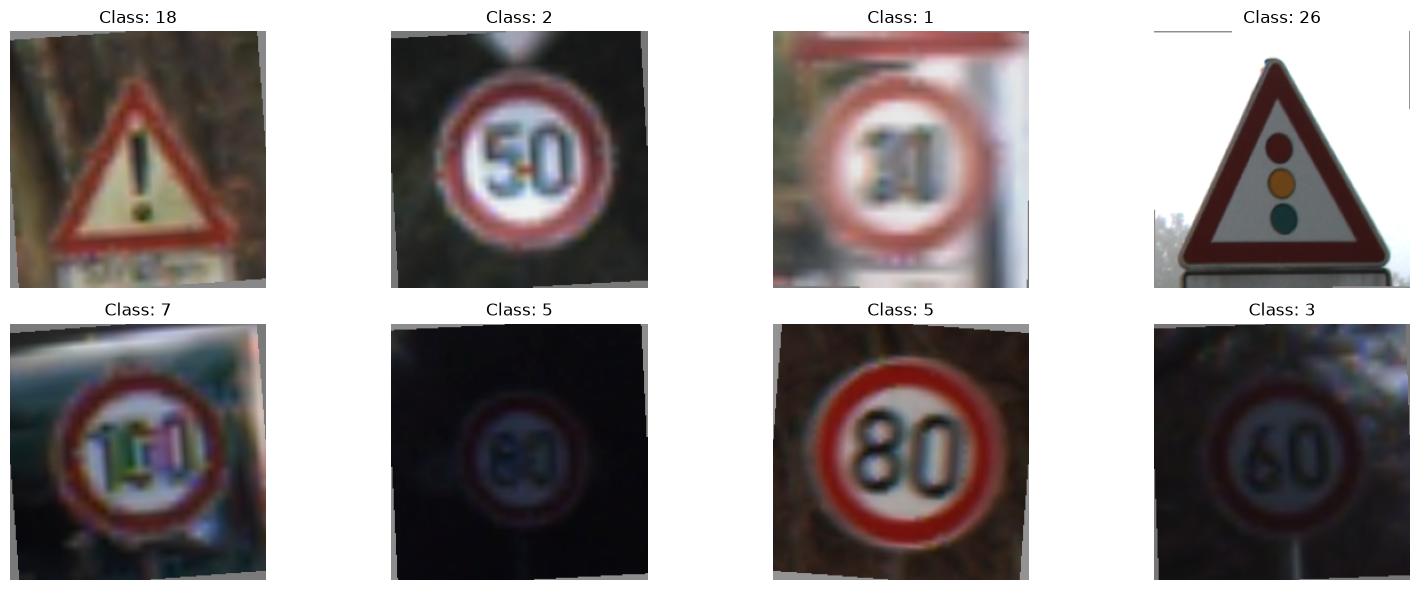

In [18]:
show_transformed_samples(train_dataset, n_samples=8)

**Visualization check:**  
The transformed training images are visible and the labels are displayed correctly. Some images appear blurry or dark because GTSRB images are originally low-resolution and are resized to 224x224 for transfer learning. Random rotation also creates small border areas around some images. This is acceptable for training augmentation, but the augmentation should remain moderate so that traffic sign shape, color, and symbol information are not damaged.

## 4.7 Check One Batch

Before moving to the model-building step, we will check one batch from the training DataLoader.

This sanity check confirms that the DataLoader is correctly returning image tensors and label tensors in the expected format for ResNet18.

For ResNet18 transfer learning, the expected image batch shape is:

```python
[batch_size, 3, 224, 224]

In [19]:
# Get one batch from the training DataLoader

images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

print("\nImage dtype:", images.dtype)
print("Label dtype:", labels.dtype)

print("\nImage min value:", images.min().item())
print("Image max value:", images.max().item())

print("\nLabel min:", labels.min().item())
print("Label max:", labels.max().item())

print("\nFirst 10 labels:", labels[:10])

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])

Image dtype: torch.float32
Label dtype: torch.int64

Image min value: -2.1179039478302
Image max value: 2.640000104904175

Label min: 1
Label max: 41

First 10 labels: tensor([ 4, 38,  2, 41, 18, 25,  8, 38,  9, 11])


In [20]:
# Confirm whether the batch is suitable for ResNet18

expected_shape = (BATCH_SIZE, 3, IMAGE_SIZE, IMAGE_SIZE)

print("Expected image shape:", expected_shape)
print("Actual image shape:", tuple(images.shape))

if tuple(images.shape) == expected_shape:
    print("Image batch shape is correct for ResNet18.")
else:
    print("Image batch shape needs checking.")

if labels.ndim == 1:
    print("Label batch shape is correct for CrossEntropyLoss.")
else:
    print("Label batch shape needs checking.")

Expected image shape: (32, 3, 224, 224)
Actual image shape: (32, 3, 224, 224)
Image batch shape is correct for ResNet18.
Label batch shape is correct for CrossEntropyLoss.


**Batch check:**  
The DataLoader successfully returns image batches with shape `[batch_size, 3, 224, 224]` and label batches with shape `[batch_size]`. The image tensors are in `float32` format and the labels are in integer class format, which is suitable for `CrossEntropyLoss`.

This confirms that the transfer learning data pipeline is complete and ready for the next step: building the ResNet18 transfer learning model.

# 5. TL Model 0: ResNet18 Feature Extractor

In this section, we will build our first transfer learning model using an ImageNet-pretrained ResNet18.

This model will be used as a **feature extractor**. That means the pretrained ResNet18 backbone will remain frozen, and only the final classifier head will be trained for the 43 GTSRB traffic sign classes.

This experiment will help us understand whether frozen ImageNet features are useful for traffic sign classification.

---

## 5.1 Why ResNet18 First?

We will start with **ResNet18** as our first transfer learning model because it is a simple, reliable, and widely used CNN architecture.

ResNet18 is smaller than many other pretrained models, so it trains faster and requires less GPU memory. This makes it a good first baseline before trying larger or more complex models.

Since ResNet18 is pretrained on ImageNet, it already learned many general visual features such as edges, colors, textures, shapes, and object boundaries. These features may help the model recognize traffic signs in the GTSRB dataset.

For this first transfer learning experiment, we will use ResNet18 as a frozen feature extractor:

```text
ImageNet-pretrained ResNet18 backbone
        ↓
Frozen feature extractor
        ↓
New classifier head for 43 GTSRB classes

## 5.2 Load Pretrained ResNet18 Weights

Now we will load an ImageNet-pretrained ResNet18 model.

Instead of starting from random weights, we will start from pretrained ImageNet weights. This allows the model to use previously learned visual features such as edges, colors, textures, shapes, and object boundaries.

We will use the modern torchvision weights API:

```python
ResNet18_Weights.DEFAULT

In [21]:
from torchvision import models
from torchvision.models import ResNet18_Weights

# Load ImageNet-pretrained ResNet18 weights
resnet18_weights = ResNet18_Weights.DEFAULT

# Create pretrained ResNet18 model
model0_resnet18 = models.resnet18(weights=resnet18_weights)

# Move model to selected device
model0_resnet18 = model0_resnet18.to(device)

print("Pretrained ResNet18 loaded successfully.")
print("Weights used:", resnet18_weights)
print("Model device:", next(model0_resnet18.parameters()).device)


Pretrained ResNet18 loaded successfully.
Weights used: ResNet18_Weights.IMAGENET1K_V1
Model device: cuda:0


In [22]:
display(model0_resnet18)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## 5.3 Inspect Original Classifier Head

Before replacing the classifier head, we need to inspect the original final layer of the pretrained ResNet18 model.

ResNet18 was originally pretrained on ImageNet, where the model predicts 1000 classes. Therefore, its original classifier head is designed for ImageNet classification, not for our 43-class GTSRB traffic sign classification task.

In this step, we will check the original `fc` layer and confirm its input and output features.

In [23]:
# Inspect the original classifier head of pretrained ResNet18

print("Original ResNet18 classifier head:")
print(model0_resnet18.fc)

print("\nInput features to classifier head:", model0_resnet18.fc.in_features)
print("Output classes from classifier head:", model0_resnet18.fc.out_features)

Original ResNet18 classifier head:
Linear(in_features=512, out_features=1000, bias=True)

Input features to classifier head: 512
Output classes from classifier head: 1000


## 5.4 Freeze All Backbone Parameters

For TL Model 0, we will use ResNet18 as a frozen feature extractor.

This means the pretrained ImageNet backbone will be used to extract visual features, but its weights will not be updated during training.

We freeze the existing parameters by setting:

```python
requires_grad = False

In [24]:
# Freeze all existing parameters of the pretrained ResNet18 model

for param in model0_resnet18.parameters():
    param.requires_grad = False

print("All existing ResNet18 parameters have been frozen.")

All existing ResNet18 parameters have been frozen.


In [25]:
# Check total and trainable parameters after freezing

total_params = sum(
    param.numel()
    for param in model0_resnet18.parameters()
)

trainable_params = sum(
    param.numel()
    for param in model0_resnet18.parameters()
    if param.requires_grad
)

frozen_params = total_params - trainable_params

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)
print("Frozen parameters:", frozen_params)

Total parameters: 11689512
Trainable parameters: 0
Frozen parameters: 11689512


## 5.5 Replace Final FC Layer for 43 Classes

The original ResNet18 classifier head was designed for 1000 ImageNet classes.

However, our GTSRB dataset has 43 traffic sign classes. Therefore, we need to replace the original final `fc` layer with a new classifier head that outputs 43 classes.

Since we already froze all existing ResNet18 parameters in the previous step, the newly added `fc` layer will be the only trainable part of TL Model 0.

In [26]:
model0_resnet18.fc

Linear(in_features=512, out_features=1000, bias=True)

In [27]:
import torch.nn as nn

# Number of classes in GTSRB
NUM_CLASSES = 43

# Get input feature size of the original ResNet18 classifier head
in_features = model0_resnet18.fc.in_features

# Replace original ImageNet classifier head with new GTSRB classifier head
model0_resnet18.fc = nn.Linear(in_features, NUM_CLASSES)

# Move model again to device because the new fc layer is newly created
model0_resnet18 = model0_resnet18.to(device)

print("Final fc layer replaced successfully.")
print("Input features:", in_features)
print("Output classes:", NUM_CLASSES)
print("New classifier head:")
print(model0_resnet18.fc)

Final fc layer replaced successfully.
Input features: 512
Output classes: 43
New classifier head:
Linear(in_features=512, out_features=43, bias=True)


In [28]:
print("FC weight trainable:", model0_resnet18.fc.weight.requires_grad)
print("FC bias trainable:", model0_resnet18.fc.bias.requires_grad)

FC weight trainable: True
FC bias trainable: True


## 5.6 Check Trainable Parameters

Now we will check which parameters are trainable in TL Model 0.

Since this model is a feature extractor, the pretrained ResNet18 backbone should remain frozen, and only the newly replaced final `fc` layer should be trainable.

This check is important because if the backbone is accidentally trainable, then the model will no longer be a pure feature extractor.

In [29]:
# Count total, trainable, and frozen parameters

total_params = sum(
    param.numel()
    for param in model0_resnet18.parameters()
)

trainable_params = sum(
    param.numel()
    for param in model0_resnet18.parameters()
    if param.requires_grad
)

frozen_params = total_params - trainable_params

trainable_percentage = (trainable_params / total_params) * 100

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)
print("Frozen parameters:", frozen_params)
print(f"Trainable percentage: {trainable_percentage:.4f}%")

Total parameters: 11198571
Trainable parameters: 22059
Frozen parameters: 11176512
Trainable percentage: 0.1970%


In [30]:
# Show only trainable parameter names

print("Trainable parameters:")

for name, param in model0_resnet18.named_parameters():
    if param.requires_grad:
        print(name, param.shape)

Trainable parameters:
fc.weight torch.Size([43, 512])
fc.bias torch.Size([43])


In [31]:
# Show only Non trainable parameter names

print("Non Trainable parameters:")

for name, param in model0_resnet18.named_parameters():
    if not param.requires_grad:
        print(name, param.shape)

Non Trainable parameters:
conv1.weight torch.Size([64, 3, 7, 7])
bn1.weight torch.Size([64])
bn1.bias torch.Size([64])
layer1.0.conv1.weight torch.Size([64, 64, 3, 3])
layer1.0.bn1.weight torch.Size([64])
layer1.0.bn1.bias torch.Size([64])
layer1.0.conv2.weight torch.Size([64, 64, 3, 3])
layer1.0.bn2.weight torch.Size([64])
layer1.0.bn2.bias torch.Size([64])
layer1.1.conv1.weight torch.Size([64, 64, 3, 3])
layer1.1.bn1.weight torch.Size([64])
layer1.1.bn1.bias torch.Size([64])
layer1.1.conv2.weight torch.Size([64, 64, 3, 3])
layer1.1.bn2.weight torch.Size([64])
layer1.1.bn2.bias torch.Size([64])
layer2.0.conv1.weight torch.Size([128, 64, 3, 3])
layer2.0.bn1.weight torch.Size([128])
layer2.0.bn1.bias torch.Size([128])
layer2.0.conv2.weight torch.Size([128, 128, 3, 3])
layer2.0.bn2.weight torch.Size([128])
layer2.0.bn2.bias torch.Size([128])
layer2.0.downsample.0.weight torch.Size([128, 64, 1, 1])
layer2.0.downsample.1.weight torch.Size([128])
layer2.0.downsample.1.bias torch.Size([128])

## 5.7 One-Batch Forward Pass

Before starting training, we will pass one batch of images through TL Model 0.

This is a sanity check to confirm that the data pipeline and model architecture are compatible.

The input image batch should have shape:

```python
[batch_size, 3, 224, 224]

In [32]:
# Get one batch from the training DataLoader

images, labels = next(iter(train_loader))

# Move batch to selected device
images = images.to(device)
labels = labels.to(device)

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Image device:", images.device)
print("Label device:", labels.device)

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Image device: cuda:0
Label device: cuda:0


In [33]:
# One-batch forward pass

model0_resnet18.eval()

with torch.no_grad():
    outputs = model0_resnet18(images)

print("Output shape:", outputs.shape)
print("Output dtype:", outputs.dtype)
print("Output device:", outputs.device)

Output shape: torch.Size([32, 43])
Output dtype: torch.float32
Output device: cuda:0


In [34]:
# Check predicted classes from raw logits

predicted_classes = outputs.argmax(dim=1)

print("First 10 true labels:", labels[:10])
print("First 10 predicted labels:", predicted_classes[:10])

First 10 true labels: tensor([15, 18, 41, 19,  1,  5,  5, 17,  3, 11], device='cuda:0')
First 10 predicted labels: tensor([38, 16,  9, 16, 32, 32, 38, 38, 38, 27], device='cuda:0')


**Forward pass check:**  
The model successfully processed one training batch and produced output logits with shape `[batch_size, 43]`. This confirms that the ResNet18 feature extractor, new classifier head, and DataLoader are compatible.

The predicted labels are not meaningful yet because the new classifier head has not been trained. The model is now ready for the training setup step.

## 5.8 Define Loss and Optimizer

Now we will define the loss function and optimizer for TL Model 0.

Since GTSRB is a multi-class classification problem with 43 classes, we will use `CrossEntropyLoss`.

For the optimizer, we will use `AdamW`. Since the pretrained backbone is frozen, the optimizer should update only the trainable parameters, which are the weights and bias of the new final `fc` layer.

This keeps TL Model 0 as a true feature extractor model.

In [35]:
# Define loss function

criterion = nn.CrossEntropyLoss()

print("Loss function:", criterion)


Loss function: CrossEntropyLoss()


In [36]:
# Define optimizer for trainable parameters only

LEARNING_RATE = 1e-3

optimizer = torch.optim.AdamW(
    params=[
        param for param in model0_resnet18.parameters()
        if param.requires_grad
    ],
    lr=LEARNING_RATE
)

print("Optimizer:", optimizer)
print("Learning rate:", LEARNING_RATE)

Optimizer: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.01
)
Learning rate: 0.001


In [37]:
# Check how many parameters the optimizer will update

optimizer_param_count = sum(
    param.numel()
    for group in optimizer.param_groups
    for param in group["params"]
)

trainable_param_count = sum(
    param.numel()
    for param in model0_resnet18.parameters()
    if param.requires_grad
)

print("Optimizer parameter count:", optimizer_param_count)
print("Trainable parameter count:", trainable_param_count)

if optimizer_param_count == trainable_param_count:
    print("Optimizer is correctly set to update only trainable parameters.")
else:
    print("Optimizer parameter setup needs checking.")

Optimizer parameter count: 22059
Trainable parameter count: 22059
Optimizer is correctly set to update only trainable parameters.


**Loss and optimizer setup:**  
`CrossEntropyLoss` is used because this is a 43-class classification problem. `AdamW` is used to optimize only the trainable parameters of TL Model 0. Since the backbone is frozen, only the new final `fc` layer will be updated during training.

## 5.9 Train Classifier Head Only

Now we will train TL Model 0.

In this experiment, ResNet18 is used as a frozen feature extractor. Therefore, the pretrained backbone will remain fixed, and only the newly replaced final `fc` layer will be trained.

During each epoch, we will:

1. train the classifier head on the training set,
2. evaluate the model on the validation set,
3. track training loss, training accuracy, validation loss, and validation accuracy.

This will help us understand whether frozen ImageNet features are useful for GTSRB traffic sign classification.

In [38]:
import copy
import time

### Helper function for feature extractor training mode

In [39]:
def set_feature_extractor_train_mode(model):
    """
    Keep the frozen pretrained backbone in eval mode
    and train only the final classifier head.
    """

    model.eval()
    model.fc.train()

### Training function for one epoch

In [40]:
def train_classifier_head_one_epoch(model, dataloader, criterion, optimizer, device):
    """
    Train only the classifier head for one epoch.
    """

    set_feature_extractor_train_mode(model)

    running_loss = 0.0
    running_corrects = 0
    total_samples = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        preds = outputs.argmax(dim=1)

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        running_corrects += (preds == labels).sum().item()
        total_samples += batch_size

    epoch_loss = running_loss / total_samples
    epoch_acc = running_corrects / total_samples

    return epoch_loss, epoch_acc

### Validation function

In [41]:
def evaluate_model(model, dataloader, criterion, device):
    """
    Evaluate model performance on validation or test data.
    """

    model.eval()

    running_loss = 0.0
    running_corrects = 0
    total_samples = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            preds = outputs.argmax(dim=1)

            batch_size = labels.size(0)
            running_loss += loss.item() * batch_size
            running_corrects += (preds == labels).sum().item()
            total_samples += batch_size

    epoch_loss = running_loss / total_samples
    epoch_acc = running_corrects / total_samples

    return epoch_loss, epoch_acc

### Train TL Model 0

In [63]:
EPOCHS = 5

model0_history = {
    "train_loss": [],
    "train_acc": [],
    "valid_loss": [],
    "valid_acc": []
}

best_valid_acc = 0.0
best_epoch = 0
best_model0_state_dict = copy.deepcopy(model0_resnet18.state_dict())

start_time = time.time()

for epoch in range(EPOCHS):
    train_loss, train_acc = train_classifier_head_one_epoch(
        model=model0_resnet18,
        dataloader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )

    valid_loss, valid_acc = evaluate_model(
        model=model0_resnet18,
        dataloader=valid_loader,
        criterion=criterion,
        device=device
    )

    model0_history["train_loss"].append(train_loss)
    model0_history["train_acc"].append(train_acc)
    model0_history["valid_loss"].append(valid_loss)
    model0_history["valid_acc"].append(valid_acc)

    if valid_acc > best_valid_acc:
        best_valid_acc = valid_acc
        best_epoch = epoch + 1
        best_model0_state_dict = copy.deepcopy(model0_resnet18.state_dict())

    print(f"Epoch [{epoch + 1}/{EPOCHS}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Valid Loss: {valid_loss:.4f} | Valid Acc: {valid_acc:.4f}")
    print("-" * 60)

end_time = time.time()
training_time = end_time - start_time

print("Training completed.")
print(f"Best Validation Accuracy: {best_valid_acc:.4f}")
print(f"Best Epoch: {best_epoch}")
print(f"Training Time: {training_time / 60:.2f} minutes")

Epoch [1/5]
Train Loss: 1.1597 | Train Acc: 0.6906
Valid Loss: 1.0083 | Valid Acc: 0.6842
------------------------------------------------------------
Epoch [2/5]
Train Loss: 0.5530 | Train Acc: 0.8488
Valid Loss: 0.9153 | Valid Acc: 0.7149
------------------------------------------------------------
Epoch [3/5]
Train Loss: 0.4245 | Train Acc: 0.8819
Valid Loss: 0.8473 | Valid Acc: 0.7294
------------------------------------------------------------
Epoch [4/5]
Train Loss: 0.3572 | Train Acc: 0.8972
Valid Loss: 0.8092 | Valid Acc: 0.7449
------------------------------------------------------------
Epoch [5/5]
Train Loss: 0.3173 | Train Acc: 0.9093
Valid Loss: 0.8414 | Valid Acc: 0.7382
------------------------------------------------------------
Training completed.
Best Validation Accuracy: 0.7449
Best Epoch: 4
Training Time: 10.35 minutes


**Training observation:**  
TL Model 0 achieved the best validation accuracy of 74.49% at epoch 4. The training accuracy continued to improve, but the validation accuracy remained much lower than the previous from-scratch CNN benchmark.

This suggests that a frozen ImageNet-pretrained ResNet18 backbone is not sufficient for strong GTSRB classification. The model can learn useful patterns from the fixed features, but those features are not fully adapted to traffic sign-specific shapes, symbols, and color patterns.

Therefore, the next logical step is to fine-tune selected later layers of ResNet18, especially `layer4`, so that the pretrained backbone can adapt to the GTSRB dataset.

## 5.10 Save Best Checkpoint

During training, we stored the model state that achieved the best validation accuracy.

Now we will save that best checkpoint so that it can be reused later for:

- validation evaluation,
- comparison with other transfer learning models,
- and Layer4 fine-tuning in the next experiment.

For TL Model 0, the best checkpoint represents the frozen ResNet18 feature extractor with the best trained classifier head.

In [ ]:
from pathlib import Path

# Create checkpoint directory
try:
    CHECKPOINT_DIR = MODEL_DIR
except NameError:
    CHECKPOINT_DIR = Path("checkpoints")

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# Checkpoint path
model0_checkpoint_path = CHECKPOINT_DIR / "tl_model0_resnet18_feature_extractor_best.pth"

# Save best checkpoint
torch.save(
    {
        "model_name": "TL Model 0 - ResNet18 Feature Extractor",
        "architecture": "resnet18",
        "weights": str(resnet18_weights),
        "num_classes": NUM_CLASSES,
        "image_size": IMAGE_SIZE,
        "imagenet_mean": IMAGENET_MEAN,
        "imagenet_std": IMAGENET_STD,
        "best_epoch": best_epoch,
        "best_valid_acc": best_valid_acc,
        "model_state_dict": best_model0_state_dict,
        "optimizer_state_dict": optimizer.state_dict(),
        "history": model0_history,
        "trainable_setup": "Frozen ResNet18 backbone + trainable final fc layer"
    },
    model0_checkpoint_path
)

print("Best checkpoint saved successfully.")
print("Checkpoint path:", model0_checkpoint_path)
print(f"Best validation accuracy: {best_valid_acc:.4f}")
print("Best epoch:", best_epoch)

**Checkpoint saved:**  
The best TL Model 0 checkpoint has been saved successfully. This checkpoint stores the best classifier-head weights based on validation accuracy and can be loaded later for evaluation or fine-tuning.

## 5.11 Plot Training Curves

Now we will visualize the training history of TL Model 0.

We will plot:

- training loss vs validation loss,
- training accuracy vs validation accuracy.

These curves help us understand whether the model is learning properly, underfitting, or overfitting.

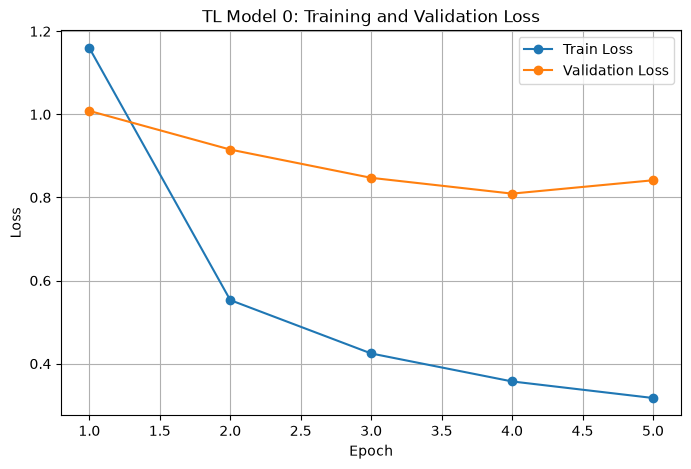

In [65]:
epochs_range = range(1, len(model0_history["train_loss"]) + 1)

plt.figure(figsize=(8, 5))

plt.plot(epochs_range, model0_history["train_loss"], marker="o", label="Train Loss")
plt.plot(epochs_range, model0_history["valid_loss"], marker="o", label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("TL Model 0: Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

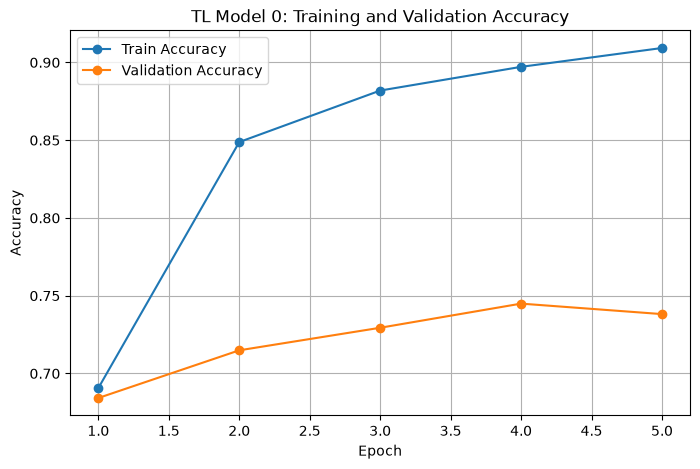

In [66]:
plt.figure(figsize=(8, 5))

plt.plot(epochs_range, model0_history["train_acc"], marker="o", label="Train Accuracy")
plt.plot(epochs_range, model0_history["valid_acc"], marker="o", label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("TL Model 0: Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [67]:
print("TL Model 0 Training Summary")
print("-" * 40)
print(f"Best validation accuracy: {best_valid_acc:.4f}")
print(f"Best epoch: {best_epoch}")
print(f"Final train accuracy: {model0_history['train_acc'][-1]:.4f}")
print(f"Final validation accuracy: {model0_history['valid_acc'][-1]:.4f}")

TL Model 0 Training Summary
----------------------------------------
Best validation accuracy: 0.7449
Best epoch: 4
Final train accuracy: 0.9093
Final validation accuracy: 0.7382


**Training curve observation:**  
The classifier head learned from the frozen ResNet18 features, but the validation accuracy remained much lower than the previous from-scratch CNN benchmark. The training accuracy increased steadily, while validation accuracy improved only up to a limited point.

This suggests that frozen ImageNet features alone are not sufficiently adapted for GTSRB traffic sign classification. Therefore, fine-tuning selected later layers of ResNet18 will be necessary in the next experiment.

## 5.12 Evaluate Validation Set

Now we will evaluate the best TL Model 0 checkpoint on the validation set.

During training, the best model was selected based on validation accuracy. In this step, we will reload that best checkpoint and calculate validation performance again.

We will report:

- validation loss,
- validation accuracy,
- macro F1 score,
- wrong prediction count,
- and classification report.

This will give us a clearer understanding of how well the frozen ResNet18 feature extractor performs on GTSRB validation data.

In [68]:
# Load best TL Model 0 checkpoint

checkpoint = torch.load(
    model0_checkpoint_path,
    map_location=device
)

model0_resnet18.load_state_dict(checkpoint["model_state_dict"])
model0_resnet18 = model0_resnet18.to(device)
model0_resnet18.eval()

print("Best TL Model 0 checkpoint loaded successfully.")
print("Model name:", checkpoint["model_name"])
print("Best epoch:", checkpoint["best_epoch"])
print(f"Best validation accuracy from training: {checkpoint['best_valid_acc']:.4f}")

Best TL Model 0 checkpoint loaded successfully.
Model name: TL Model 0 - ResNet18 Feature Extractor
Best epoch: 4
Best validation accuracy from training: 0.7449


In [69]:
# Evaluate best TL Model 0 on validation set

model0_valid_loss, model0_valid_acc = evaluate_model(
    model=model0_resnet18,
    dataloader=valid_loader,
    criterion=criterion,
    device=device
)

print("TL Model 0 Validation Evaluation")
print("-" * 40)
print(f"Validation Loss: {model0_valid_loss:.4f}")
print(f"Validation Accuracy: {model0_valid_acc:.4f}")

TL Model 0 Validation Evaluation
----------------------------------------
Validation Loss: 0.8092
Validation Accuracy: 0.7449


In [70]:
# Collect validation predictions and true labels

all_valid_preds = []
all_valid_labels = []

model0_resnet18.eval()

with torch.no_grad():
    for images, labels in valid_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model0_resnet18(images)
        preds = outputs.argmax(dim=1)

        all_valid_preds.extend(preds.cpu().numpy())
        all_valid_labels.extend(labels.cpu().numpy())

print("Validation predictions collected.")
print("Total validation samples:", len(all_valid_labels))

Validation predictions collected.
Total validation samples: 7860


In [71]:
from sklearn.metrics import accuracy_score, f1_score

model0_val_accuracy = accuracy_score(all_valid_labels, all_valid_preds)
model0_val_macro_f1 = f1_score(
    all_valid_labels,
    all_valid_preds,
    average="macro",
    zero_division=0
)

wrong_predictions = sum(
    true_label != pred_label
    for true_label, pred_label in zip(all_valid_labels, all_valid_preds)
)

total_predictions = len(all_valid_labels)
wrong_prediction_rate = wrong_predictions / total_predictions

print("TL Model 0 Validation Metrics")
print("-" * 40)
print(f"Validation Accuracy: {model0_val_accuracy:.4f}")
print(f"Macro F1 Score: {model0_val_macro_f1:.4f}")
print(f"Wrong Predictions: {wrong_predictions} / {total_predictions}")
print(f"Wrong Prediction Rate: {wrong_prediction_rate:.4f}")

TL Model 0 Validation Metrics
----------------------------------------
Validation Accuracy: 0.7449
Macro F1 Score: 0.6430
Wrong Predictions: 2005 / 7860
Wrong Prediction Rate: 0.2551


In [72]:
from sklearn.metrics import classification_report

print("TL Model 0 Validation Classification Report")
print("-" * 60)

print(
    classification_report(
        all_valid_labels,
        all_valid_preds,
        labels=list(range(NUM_CLASSES)),
        digits=4,
        zero_division=0
    )
)

TL Model 0 Validation Classification Report
------------------------------------------------------------
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000        30
           1     0.7626    0.6067    0.6757       450
           2     0.5285    0.6800    0.5948       450
           3     0.5861    0.5926    0.5893       270
           4     0.6759    0.7538    0.7127       390
           5     0.6364    0.7389    0.6838       360
           6     1.0000    0.8222    0.9024        90
           7     0.8274    0.8467    0.8369       300
           8     0.8981    0.5222    0.6604       270
           9     0.8880    0.7400    0.8073       300
          10     0.6586    0.9051    0.7624       390
          11     0.8352    0.8259    0.8305       270
          12     0.9870    0.9048    0.9441       420
          13     0.9530    0.9467    0.9498       450
          14     1.0000    0.9867    0.9933       150
          15     0.9848    0.8

**Validation evaluation observation:**  
TL Model 0 was evaluated using the best saved checkpoint. The model uses a frozen ImageNet-pretrained ResNet18 backbone and only a trained final classifier head.

The validation result shows how much performance we can get from fixed ImageNet features without fine-tuning the backbone. Since the validation accuracy is still much lower than the previous from-scratch CNN benchmark, this confirms that feature extraction alone is not sufficient for strong GTSRB classification.

The next logical step is to fine-tune selected later layers of ResNet18 so that the pretrained backbone can adapt to traffic sign-specific features.

# 6. TL Model 1: ResNet18 Fine-Tuning Layer4

In the previous experiment, TL Model 0 used ResNet18 as a frozen feature extractor. The pretrained backbone remained fixed, and only the final classifier head was trained for the 43 GTSRB classes.

However, the validation performance of the frozen feature extractor was limited. This suggests that ImageNet features are useful, but they are not fully adapted to traffic sign-specific patterns.

In this section, we will improve the transfer learning model by fine-tuning the last major block of ResNet18: `layer4`.

The goal of this experiment is to check whether allowing the later pretrained layers to adapt to GTSRB can improve validation performance.

---

## 6.1 Why Fine-Tune Only Layer4?

ResNet18 is made of several feature-learning stages:

$$
\text{Conv1} \rightarrow \text{Layer1} \rightarrow \text{Layer2} \rightarrow \text{Layer3} \rightarrow \text{Layer4} \rightarrow \text{FC}
$$

Earlier layers usually learn general visual features such as:

$$
\text{edges}, \text{corners}, \text{colors}, \text{textures}
$$

These features are useful for many image datasets, including GTSRB. Therefore, we will keep the earlier layers frozen.

Later layers learn more task-specific and high-level features such as:

$$
\text{object shapes}, \text{class-specific patterns}, \text{semantic visual features}
$$

For GTSRB, these later features need to adapt to traffic sign-specific patterns such as:

$$
\text{circle signs}, \text{triangle signs}, \text{red borders}, \text{speed numbers}, \text{warning symbols}
$$

In TL Model 0, the full backbone was frozen:

$$
\text{Conv1, Layer1, Layer2, Layer3, Layer4} = \text{frozen}
$$

$$
\text{FC} = \text{trainable}
$$

So only the classifier head learned from GTSRB.

In TL Model 1, we will fine-tune `layer4` and the final classifier head:

$$
\text{Conv1, Layer1, Layer2, Layer3} = \text{frozen}
$$

$$
\text{Layer4, FC} = \text{trainable}
$$

Mathematically, the frozen feature extractor model was:

$$
f(x) = h_{\text{new}}(g(x; W_{\text{ImageNet}}))
$$

where:

$$
W_{\text{ImageNet}} = \text{fixed pretrained backbone weights}
$$

For layer4 fine-tuning, we can think of the model as:

$$
f(x) = h_{\text{new}}(g(x; W_{\text{early}}, W_{\text{layer4}}))
$$

where:

$$
W_{\text{early}} = \text{frozen early backbone weights}
$$

$$
W_{\text{layer4}} = \text{trainable layer4 weights}
$$

$$
W_{\text{fc}} = \text{trainable classifier head weights}
$$

This means the model still keeps most of its ImageNet knowledge, but the last feature block can adapt to the GTSRB traffic sign dataset.

---

### Why not fine-tune the whole model first?

Fine-tuning the whole model would update many more parameters. This can increase:

- training time,
- GPU memory usage,
- overfitting risk,
- and the chance of damaging useful pretrained features.

Since GTSRB traffic signs are visually specific but not extremely complex, fine-tuning only `layer4` is a safe and controlled first improvement.

---

### Project decision

For TL Model 1, we will start from the best TL Model 0 checkpoint and unfreeze only:

$$
\text{Layer4} + \text{FC}
$$

This gives the model more flexibility than feature extraction, while still keeping most of the pretrained backbone stable.

The goal is to test whether limited fine-tuning can improve performance over the frozen ResNet18 feature extractor baseline.

## 6.2 Load TL Model 0 Best Checkpoint

Now we will load the best checkpoint from TL Model 0.

This checkpoint contains the frozen ResNet18 feature extractor model with the best trained final classifier head from the previous experiment.

We will use this checkpoint as the starting point for TL Model 1, where `layer4` and the final `fc` layer will be fine-tuned.

In [49]:
from pathlib import Path
import torch
import torch.nn as nn
from torchvision import models
from torchvision.models import ResNet18_Weights

# Make sure basic constants exist
NUM_CLASSES = 43

try:
    device
except NameError:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Check possible checkpoint locations
possible_checkpoint_dirs = []

try:
    possible_checkpoint_dirs.append(TRAINED_MODEL_DIR)
except NameError:
    pass

try:
    possible_checkpoint_dirs.append(MODEL_DIR)
except NameError:
    pass

possible_checkpoint_dirs.extend([
    Path("checkpoints"),
    Path("Trained_model"),
    Path.cwd(),
    Path.cwd().parent / "Trained_model",
    Path.cwd().parent / "checkpoints"
])

checkpoint_filename = "tl_model0_resnet18_feature_extractor_best.pth"

model0_checkpoint_path = None

for checkpoint_dir in possible_checkpoint_dirs:
    checkpoint_dir = Path(checkpoint_dir)
    candidate_path = checkpoint_dir / checkpoint_filename
    
    if candidate_path.exists():
        model0_checkpoint_path = candidate_path
        break

if model0_checkpoint_path is None:
    found_files = list(Path.cwd().rglob(checkpoint_filename))
    
    if len(found_files) > 0:
        model0_checkpoint_path = found_files[0]

if model0_checkpoint_path is None:
    raise FileNotFoundError(
        f"{checkpoint_filename} not found. Please rerun Step 5.10 to save the best checkpoint."
    )

print("Checkpoint found:")
print(model0_checkpoint_path)

Checkpoint found:
checkpoints\tl_model0_resnet18_feature_extractor_best.pth


In [61]:
# Recreate ResNet18 architecture for TL Model 1

resnet18_weights = ResNet18_Weights.DEFAULT

model1_resnet18 = models.resnet18(weights=resnet18_weights)

in_features = model1_resnet18.fc.in_features
model1_resnet18.fc = nn.Linear(in_features, NUM_CLASSES)

model1_resnet18 = model1_resnet18.to(device)

print("ResNet18 architecture recreated for TL Model 1.")
print("Classifier head:")
print(model1_resnet18.fc)

ResNet18 architecture recreated for TL Model 1.
Classifier head:
Linear(in_features=512, out_features=43, bias=True)


In [65]:
# Load TL Model 0 best checkpoint

checkpoint = torch.load(
    model0_checkpoint_path,
    map_location=device
)

model1_resnet18.load_state_dict(checkpoint["model_state_dict"])

model1_resnet18 = model1_resnet18.to(device)

print("TL Model 0 best checkpoint loaded successfully.")
print("Loaded model:", checkpoint.get("model_name", "Unknown"))
print("Best epoch:", checkpoint.get("best_epoch", "Unknown"))
print("Best validation accuracy:", checkpoint.get("best_valid_acc", "Unknown"))

TL Model 0 best checkpoint loaded successfully.
Loaded model: TL Model 0 - ResNet18 Feature Extractor
Best epoch: 4
Best validation accuracy: 0.7449109414758269


**Checkpoint loading check:**  
The best TL Model 0 checkpoint has been loaded successfully into a new ResNet18 model. This model will now be used as the starting point for Layer4 fine-tuning in TL Model 1.

## 6.3 Unfreeze Layer4 and Classifier Head

Now we will prepare TL Model 1 for limited fine-tuning.

We will keep the early ResNet18 layers frozen and unfreeze only `layer4` and the final `fc` classifier head.

This setup allows the model to adapt high-level ImageNet features to GTSRB traffic sign patterns while keeping the earlier general visual features stable.

The trainable setup will be:

```text
Conv1, Layer1, Layer2, Layer3 → frozen
Layer4, FC → trainable

In [66]:
# Freeze all parameters first to reset the trainable setup

for param in model1_resnet18.parameters():
    param.requires_grad = False

print("All parameters frozen first.")

All parameters frozen first.


In [67]:
# Unfreeze layer4 parameters

for param in model1_resnet18.layer4.parameters():
    param.requires_grad = True

# Unfreeze final classifier head parameters

for param in model1_resnet18.fc.parameters():
    param.requires_grad = True

print("Layer4 and fc layer are now trainable.")

Layer4 and fc layer are now trainable.


In [71]:
# Check which layers are trainable

print("Trainable parameters:")

for name, param in model1_resnet18.named_parameters():
    if param.requires_grad:
        print(name, param.shape)

Trainable parameters:
layer4.0.conv1.weight torch.Size([512, 256, 3, 3])
layer4.0.bn1.weight torch.Size([512])
layer4.0.bn1.bias torch.Size([512])
layer4.0.conv2.weight torch.Size([512, 512, 3, 3])
layer4.0.bn2.weight torch.Size([512])
layer4.0.bn2.bias torch.Size([512])
layer4.0.downsample.0.weight torch.Size([512, 256, 1, 1])
layer4.0.downsample.1.weight torch.Size([512])
layer4.0.downsample.1.bias torch.Size([512])
layer4.1.conv1.weight torch.Size([512, 512, 3, 3])
layer4.1.bn1.weight torch.Size([512])
layer4.1.bn1.bias torch.Size([512])
layer4.1.conv2.weight torch.Size([512, 512, 3, 3])
layer4.1.bn2.weight torch.Size([512])
layer4.1.bn2.bias torch.Size([512])
fc.weight torch.Size([43, 512])
fc.bias torch.Size([43])


In [72]:
for name, param in model1_resnet18.named_parameters():
    if not param.requires_grad:
        print(name, param.shape)

conv1.weight torch.Size([64, 3, 7, 7])
bn1.weight torch.Size([64])
bn1.bias torch.Size([64])
layer1.0.conv1.weight torch.Size([64, 64, 3, 3])
layer1.0.bn1.weight torch.Size([64])
layer1.0.bn1.bias torch.Size([64])
layer1.0.conv2.weight torch.Size([64, 64, 3, 3])
layer1.0.bn2.weight torch.Size([64])
layer1.0.bn2.bias torch.Size([64])
layer1.1.conv1.weight torch.Size([64, 64, 3, 3])
layer1.1.bn1.weight torch.Size([64])
layer1.1.bn1.bias torch.Size([64])
layer1.1.conv2.weight torch.Size([64, 64, 3, 3])
layer1.1.bn2.weight torch.Size([64])
layer1.1.bn2.bias torch.Size([64])
layer2.0.conv1.weight torch.Size([128, 64, 3, 3])
layer2.0.bn1.weight torch.Size([128])
layer2.0.bn1.bias torch.Size([128])
layer2.0.conv2.weight torch.Size([128, 128, 3, 3])
layer2.0.bn2.weight torch.Size([128])
layer2.0.bn2.bias torch.Size([128])
layer2.0.downsample.0.weight torch.Size([128, 64, 1, 1])
layer2.0.downsample.1.weight torch.Size([128])
layer2.0.downsample.1.bias torch.Size([128])
layer2.1.conv1.weight tor

**Unfreezing check:**  
Only `layer4` and the final `fc` classifier head are now trainable. The earlier ResNet18 layers remain frozen, so the model keeps most of its ImageNet pretrained knowledge while allowing the last feature block to adapt to GTSRB traffic sign-specific patterns.